In [1]:
!pip install torch joblib scikit-learn matplotlib pandas

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("/kaggle/input/datasets/ngyyenhon/iotdtt/iot.csv")
df.head()

,Device_ID,Temperature,Humidity,Battery_Level,Anomaly
0,DHT11_B,-0.555734,-0.157264,0.377032,0
1,DHT11_A,-0.266879,-0.086229,-0.217410,0
2,DHT11_B,0.128544,0.041150,0.090479,0
3,TEST_SENSOR_999,99.999000,88.888000,77.777000,1
4,DHT11_D,-1.001516,-0.320621,-0.705341,0


In [4]:
df.describe()
df["Device_ID"].value_counts()
df["Anomaly"].value_counts()

Anomaly
0    2478
1     523
Name: count, dtype: int64

In [5]:
df.isna().sum()

Device_ID        0
Temperature      0
Humidity         0
Battery_Level    0
Anomaly          0
dtype: int64

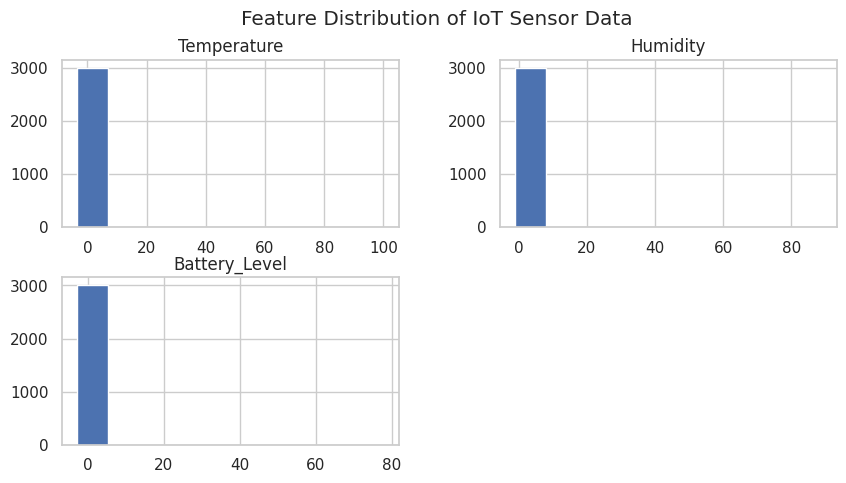

In [6]:
df[['Temperature', 'Humidity', 'Battery_Level']].hist(figsize=(10,5))
plt.suptitle("Feature Distribution of IoT Sensor Data")
plt.show()

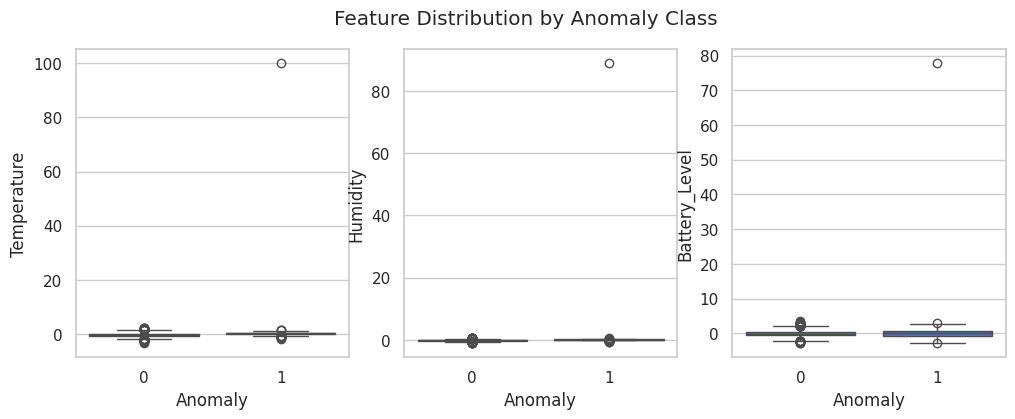

In [7]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.boxplot(x='Anomaly', y='Temperature', data=df)

plt.subplot(1,3,2)
sns.boxplot(x='Anomaly', y='Humidity', data=df)

plt.subplot(1,3,3)
sns.boxplot(x='Anomaly', y='Battery_Level', data=df)

plt.suptitle("Feature Distribution by Anomaly Class")
plt.show()

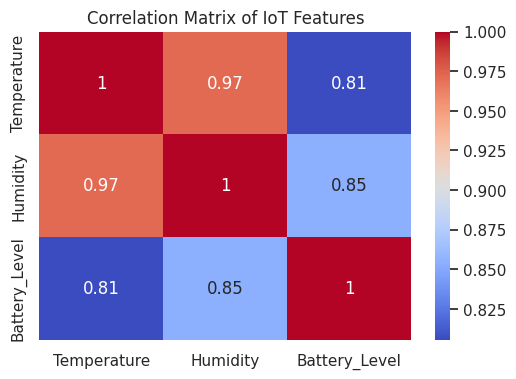

In [8]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Temperature','Humidity','Battery_Level']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of IoT Features")
plt.show()

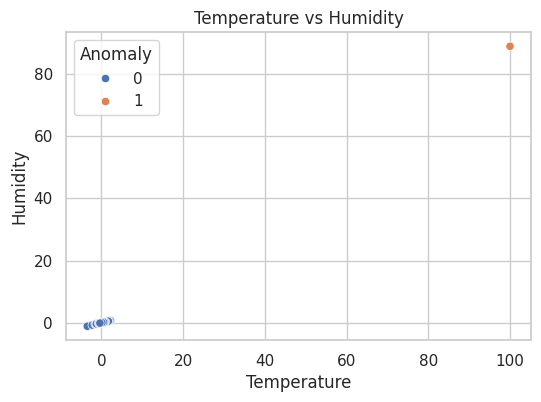

In [9]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Temperature', y='Humidity', hue='Anomaly', data=df)
plt.title("Temperature vs Humidity")
plt.show()

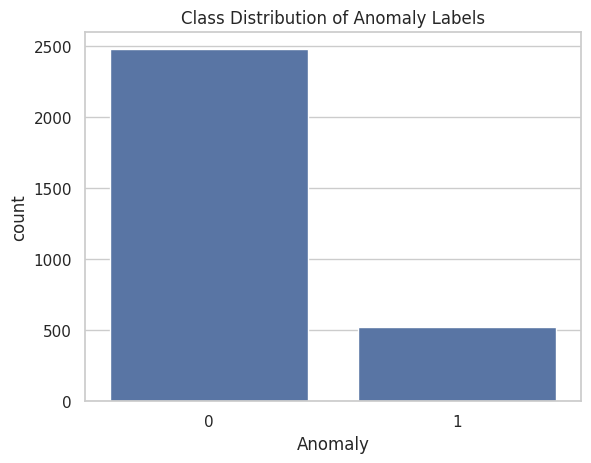

Anomaly
0    0.825725
1    0.174275
Name: proportion, dtype: float64


In [10]:
sns.countplot(x='Anomaly', data=df)
plt.title("Class Distribution of Anomaly Labels")
plt.show()

print(df['Anomaly'].value_counts(normalize=True))

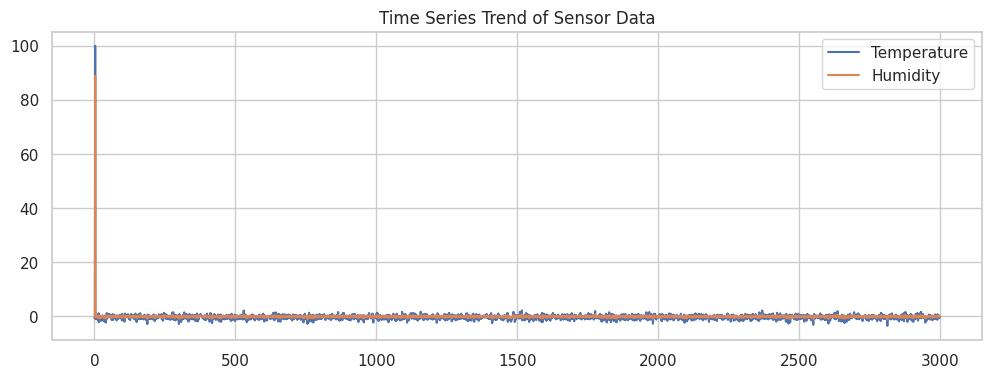

In [11]:
plt.figure(figsize=(12,4))
plt.plot(df['Temperature'], label='Temperature')
plt.plot(df['Humidity'], label='Humidity')
plt.legend()
plt.title("Time Series Trend of Sensor Data")
plt.show()

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score


cols = ["Temperature", "Humidity", "Battery_Level", "Anomaly"]
df = df[cols].copy()

df[cols] = df[cols].apply(pd.to_numeric, errors="coerce")

df = df.dropna().reset_index(drop=True)

features = ["Temperature", "Humidity", "Battery_Level"]

print(df.head())
print(df["Anomaly"].value_counts())

   Temperature   Humidity  Battery_Level  Anomaly
0    -0.555734  -0.157264       0.377032        0
1    -0.266879  -0.086229      -0.217410        0
2     0.128544   0.041150       0.090479        0
3    99.999000  88.888000      77.777000        1
4    -1.001516  -0.320621      -0.705341        0
Anomaly
0    2478
1     523
Name: count, dtype: int64


In [27]:
n = len(df)
train_end = int(n * 0.8)

train_df = df.iloc[:train_end].copy()
test_df  = df.iloc[train_end:].copy()

print("Train:", train_df.shape)
print("Test :", test_df.shape)

Train: (2400, 4)
Test : (601, 4)


In [28]:
scaler = StandardScaler()

train_df_scaled = train_df.copy()
test_df_scaled  = test_df.copy()

train_df_scaled[features] = scaler.fit_transform(train_df[features])
test_df_scaled[features]  = scaler.transform(test_df[features])

In [52]:
X_train_normal = train_df_scaled[train_df_scaled["Anomaly"] == 0][features]
X_val = val_df_scaled[features]
y_val = val_df_scaled["Anomaly"].values

X_test = test_df_scaled[features]
y_test = test_df_scaled["Anomaly"].values

In [53]:
from sklearn.ensemble import IsolationForest

X_train_normal = train_df_scaled[train_df_scaled["Anomaly"] == 0][features]
X_test = test_df_scaled[features]
y_test = test_df_scaled["Anomaly"].values

iso_model = IsolationForest(
    n_estimators=500,
    max_samples="auto",
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

iso_model.fit(X_train_normal)

IsolationForest(n_estimators=500, n_jobs=-1, random_state=42)

In [59]:
train_scores = -iso_model.score_samples(X_train_normal)
test_scores  = -iso_model.score_samples(X_test)

threshold_iso = np.quantile(train_scores, 0.96)

pred_test_iso = (test_scores >= threshold_iso).astype(int)

print("Threshold:", threshold_iso)
print(classification_report(y_test, pred_test_iso, digits=2))

Threshold: 0.6084165090655246
              precision    recall  f1-score   support

           0       0.82      0.95      0.88       492
           1       0.23      0.06      0.10       109

    accuracy                           0.79       601
   macro avg       0.52      0.51      0.49       601
weighted avg       0.71      0.79      0.74       601



In [34]:
WINDOW = 50

def create_sequences(data, labels, window):
    X, y = [], []
    for i in range(len(data) - window + 1):
        X.append(data[i:i+window])
        y.append(labels[i + window - 1])   # nhãn của điểm cuối cửa sổ
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(
    train_df_scaled[features].values,
    train_df_scaled["Anomaly"].values,
    WINDOW
)

X_test, y_test_seq = create_sequences(
    test_df_scaled[features].values,
    test_df_scaled["Anomaly"].values,
    WINDOW
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test_seq.shape)

X_train: (2351, 50, 3)
y_train: (2351,)
X_test : (552, 50, 3)
y_test : (552,)


In [36]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(SeqDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader  = DataLoader(SeqDataset(X_test, y_test_seq), batch_size=64, shuffle=False)

In [37]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )
        self.fc = nn.Linear(128, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

In [45]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = LSTMClassifier(input_size=len(features)).to(device)

pos = y_train.sum()
neg = len(y_train) - pos
pos_weight = torch.tensor([neg / (pos + 1e-8)], dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 30

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device).unsqueeze(1)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {total_loss / len(train_loader):.4f}")

Epoch 1/30 - Loss: 0.5023
Epoch 2/30 - Loss: 0.4634
Epoch 3/30 - Loss: 0.4597
Epoch 4/30 - Loss: 0.4532
Epoch 5/30 - Loss: 0.4284
Epoch 6/30 - Loss: 0.4139
Epoch 7/30 - Loss: 0.4012
Epoch 8/30 - Loss: 0.4066
Epoch 9/30 - Loss: 0.4014
Epoch 10/30 - Loss: 0.3974
Epoch 11/30 - Loss: 0.3930
Epoch 12/30 - Loss: 0.3921
Epoch 13/30 - Loss: 0.3905
Epoch 14/30 - Loss: 0.3888
Epoch 15/30 - Loss: 0.3850
Epoch 16/30 - Loss: 0.3839
Epoch 17/30 - Loss: 0.3814
Epoch 18/30 - Loss: 0.3795
Epoch 19/30 - Loss: 0.3788
Epoch 20/30 - Loss: 0.3751
Epoch 21/30 - Loss: 0.3769
Epoch 22/30 - Loss: 0.3731
Epoch 23/30 - Loss: 0.3714
Epoch 24/30 - Loss: 0.3696
Epoch 25/30 - Loss: 0.3726
Epoch 26/30 - Loss: 0.3700
Epoch 27/30 - Loss: 0.3612
Epoch 28/30 - Loss: 0.3634
Epoch 29/30 - Loss: 0.3628
Epoch 30/30 - Loss: 0.3606


In [46]:
model.eval()
test_probs = []
test_true = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        probs = torch.sigmoid(model(xb)).cpu().numpy().flatten()
        test_probs.extend(probs)
        test_true.extend(yb.numpy())

test_probs = np.array(test_probs)
test_true = np.array(test_true)

pred_test_lstm = (test_probs >= 0.5).astype(int)

print("Threshold: 0.5")
print(classification_report(test_true, pred_test_lstm, digits=2))

Threshold: 0.5
              precision    recall  f1-score   support

         0.0       0.83      0.94      0.88       448
         1.0       0.37      0.15      0.22       104

    accuracy                           0.79       552
   macro avg       0.60      0.55      0.55       552
weighted avg       0.74      0.79      0.76       552



In [60]:
X_train_normal_raw = train_df[train_df["Anomaly"] == 0][features].values

mean_vec = X_train_normal_raw.mean(axis=0)
std_vec  = X_train_normal_raw.std(axis=0) + 1e-8

print("Mean:", mean_vec)
print("Std :", std_vec)

Mean: [-0.3329781  -0.10098611 -0.02563419]
Std : [0.69729487 0.21408632 0.84839822]


In [61]:
def stat_score(X, mean_vec, std_vec):
    z = np.abs((X - mean_vec) / std_vec)
    z_mean = np.mean(z, axis=1)
    return z_mean

In [62]:
train_stat_scores = stat_score(X_train_normal_raw, mean_vec, std_vec)

X_test_raw = test_df[features].values
y_test_raw = test_df["Anomaly"].values

test_stat_scores = stat_score(X_test_raw, mean_vec, std_vec)

threshold_stat = np.quantile(train_stat_scores, 0.96)

pred_test_stat = (test_stat_scores >= threshold_stat).astype(int)

print("Threshold:", threshold_stat)
print(classification_report(y_test_raw, pred_test_stat, digits=2))

Threshold: 1.8692647370646576
              precision    recall  f1-score   support

           0       0.82      0.96      0.88       492
           1       0.12      0.03      0.04       109

    accuracy                           0.79       601
   macro avg       0.47      0.49      0.46       601
weighted avg       0.69      0.79      0.73       601



In [50]:
print("Isolation Forest predicted anomalies:", pred_test_iso.sum())
print("Statistical predicted anomalies:", pred_test_stat.sum())

Isolation Forest predicted anomalies: 8
Statistical predicted anomalies: 8


In [ ]:
Isolation Forest predicted anomalies: 8
Statistical predicted anomalies: 8